# Open WOD datasets, Aug-Nov 2014-2020 for Beaufort Sea Region

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gsw
import os

**DATASETS**<br>
OSD Ocean Station Data<br>
CTD High-resolution Conductivity-Temperature-Depth / XCTD data<br>
APB Autonomous Pinniped Bathythermograph data<br>
PFL Profiling float data<br>
DRB Drifting buoy data<br>
GLD Glider data<br>

### Open datasets and standardize depths

In [10]:
# pinn_tmp = xr.open_dataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/APB/wod_017301912O.nc')
pinn_tmp = xr.open_dataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/APB/wod_017807239O.nc')

In [12]:
pinn_tmp.z.values

array([ 2.,  4.,  5.,  7.,  9., 11., 12., 14., 16., 17., 19., 21., 22.,
       24., 26., 28.], dtype=float32)

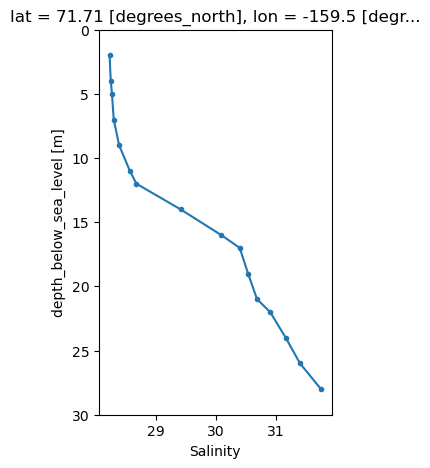

In [23]:
pinn_tmp.Salinity.plot(y='z',marker='.',figsize=[3,5]);
plt.ylim(30,0);

In [15]:
# ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/CTD/*wod*") # ctd
# ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/APB/*wod*") # pinniped
# ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/DRB/*wod*") # drifting buoy
# ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/OSD/*wod*") # ocean station data
# ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/PFL/*wod*") # profiling float
ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/GLD/*wod*") # glider
# print(ctd_filenames)

# new z coordinate
z_coords = np.arange(0,200,1)

# loop through each file, open it, standardize depths, and save new ds
for file in ctd_filenames:
    ds = xr.open_dataset(file)

    # ds.Salinity.plot(y='z')
    # plt.ylim(100,0)
    
    # interpolate all variables along the z dimension
    ds_interp = ds.interp(z=z_coords)

    # keep only Temperature and Salinity (if they exist in the dataset)
    # keep_vars = [v for v in ["Temperature", "Salinity"] if v in ds_interp.data_vars]
    keep_vars = [v for v in ["Temperature", "Salinity", "Temperature_WODprofileflag", "Temperature_WODflag", "Salinity_WODprofileflag", "Salinity_WODflag"] if v in ds_interp.data_vars]
    ds_filtered = ds_interp[keep_vars]

    # preserve coordinates like lat, lon, time
    for coord in ds_interp.coords:
        if coord not in ds_filtered.coords:
            ds_filtered = ds_filtered.assign_coords({coord: ds_interp[coord]})

    # expand to include time as a dimension (if applicable)
    ds_new = ds_filtered.expand_dims(time=[ds_interp.time.values])

    # define new path and save if profile passes Salinity QC
    if ds_new.Salinity_WODprofileflag.values==0:
        
        # pull out time for filename
        t = pd.to_datetime(ds_new.time.values[0])
        date = t.strftime("%Y%m%d")

        # Split path
        base_dir, old_filename = os.path.split(file)
        
        # Extract region code
        region_code = os.path.basename(base_dir)
        
        # Extract profile number from old filename
        profile_number = old_filename.replace('wod_', '').replace('.nc', '')
        
        # Build new directory path
        new_dir = file.replace('raw_depths', 'standard_depths')
        
        # Build new filename keeping profile number
        new_filename = f'wod_{profile_number}_{date}_standard_depths.nc'
        
        # Combine new directory and new filename
        new_path = os.path.join(os.path.dirname(new_dir), new_filename)

        # save ds
        ds_new.to_netcdf(new_path)
        print(f"Saved standardized dataset: {new_path}")

    ds.close()
    ds_new.close()

Saved standardized dataset: /Users/mzahn/data/SASSIE/WOD/standard_depths/GLD/wod_016596565O_20141008_standard_depths.nc


In [164]:
# ctd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/CTD/*.nc')
# drb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/DRB/*.nc')
# osd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/OSD/*.nc')
# pfl_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/PFL/*.nc')
apb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/APB/*.nc')

(100.0, 0.0)

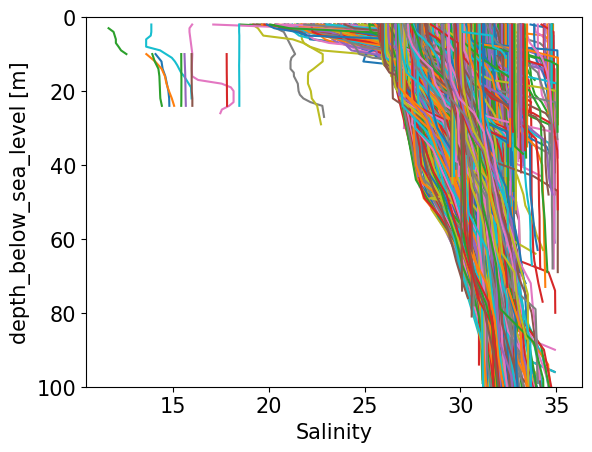

In [166]:
apb_ds.Salinity.plot(hue='time',y='z',add_legend=False)
plt.ylim(100,0)